# Rotating Beam with a Swept Tip

In this example we analyze a rotating beam with a swept tip.  The parameters for this
example come from "Finite element solution of nonlinear intrinsic equations for curved
composite beams" by Hodges, Shang, and Cesnik.

![](../assets/rotating-drawing.svg)

## Steady State Analysis

In [1]:
using GXBeam, LinearAlgebra

sweep = 45 * pi/180
rpm = 0:25:750

# straight section of the beam
L_b1 = 31.5 ## inch
r_b1 = [2.5, 0, 0]
nelem_b1 = 13
lengths_b1, xp_b1, xm_b1, Cab_b1 = discretize_beam(L_b1, r_b1, nelem_b1)

# swept section of the beam
L_b2 = 6 ## inch
r_b2 = [34, 0, 0]
nelem_b2 = 3
cs, ss = cos(sweep), sin(sweep)
frame_b2 = [cs ss 0; -ss cs 0; 0 0 1]
lengths_b2, xp_b2, xm_b2, Cab_b2 = discretize_beam(L_b2, r_b2, nelem_b2;
    frame = frame_b2)

# combine elements and points into one array
nelem = nelem_b1 + nelem_b2
points = vcat(xp_b1, xp_b2[2:end])
start = 1:nelem_b1 + nelem_b2
stop = 2:nelem_b1 + nelem_b2 + 1
lengths = vcat(lengths_b1, lengths_b2)
midpoints = vcat(xm_b1, xm_b2)
Cab = vcat(Cab_b1, Cab_b2)

# cross section
w = 1 ## inch
h = 0.063 ## inch

# material properties
E = 1.06e7 ## lb/in^2
ν = 0.325
ρ = 2.51e-4 ## lb sec^2/in^4

# shear and torsion correction factors
ky = 1.2000001839588001
kz = 14.625127919304001
kt = 65.85255016982444

A = h*w
Iyy = w*h^3/12
Izz = w^3*h/12
J = Iyy + Izz

# apply corrections
Ay = A/ky
Az = A/kz
Jx = J/kt

G = E/(2*(1+ν))

compliance = fill(Diagonal([1/(E*A), 1/(G*Ay), 1/(G*Az), 1/(G*Jx), 1/(E*Iyy),
    1/(E*Izz)]), nelem)

mass = fill(Diagonal([ρ*A, ρ*A, ρ*A, ρ*J, ρ*Iyy, ρ*Izz]), nelem)

# create assembly
assembly = Assembly(points, start, stop;
    compliance = compliance,
    mass = mass,
    frames = Cab,
    lengths = lengths,
    midpoints = midpoints)

# create dictionary of prescribed conditions
prescribed_conditions = Dict(
    # root section is fixed
    1 => PrescribedConditions(ux=0, uy=0, uz=0, theta_x=0, theta_y=0, theta_z=0)
    )

nonlinear_states = Vector{AssemblyState{Float64}}(undef, length(rpm))
linear_states = Vector{AssemblyState{Float64}}(undef, length(rpm))
for i = 1:length(rpm)
    # global frame rotation
    w0 = [0, 0, rpm[i]*(2*pi)/60]

    # perform linear steady state analysis
    system, linear_states[i], converged = steady_state_analysis(assembly,
        angular_velocity = w0,
        prescribed_conditions = prescribed_conditions,
        linear = true)

    # perform nonlinear steady state analysis
    system, nonlinear_states[i], converged = steady_state_analysis(assembly,
        angular_velocity = w0,
        prescribed_conditions = prescribed_conditions)

end

nothing ##hide

To visualize the solutions we will plot the root moment and tip deflections against the
angular speed.

In [2]:
using Plots
pyplot()
colors = get_color_palette(:auto, 17)
nothing #hide

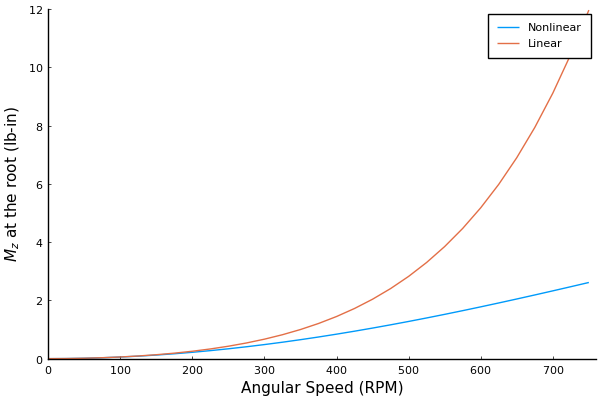

In [3]:
# root moment
plot(
    xlim = (0, 760),
    xticks = 0:100:750,
    xlabel = "Angular Speed (RPM)",
    ylim = (0, 12),
    yticks = 0.0:2:12,
    ylabel = "\$M_z\$ at the root (lb-in)",
    grid = false,
    overwrite_figure=false
    )
Mz_nl = [-nonlinear_states[i].points[1].M[3] for i = 1:length(rpm)]
Mz_l = [-linear_states[i].points[1].M[3] for i = 1:length(rpm)]
plot!(rpm, Mz_nl, label="Nonlinear")
plot!(rpm, Mz_l, label="Linear")

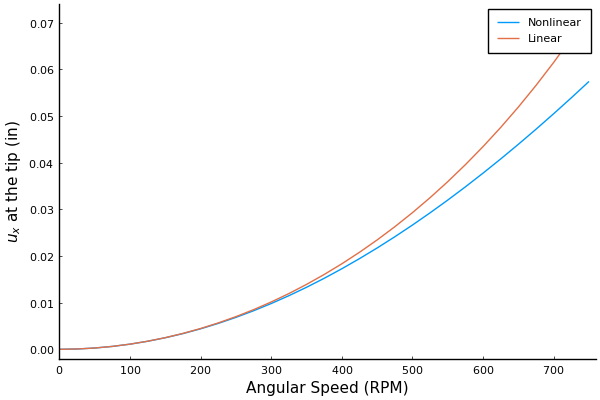

In [4]:
# x tip deflection
plot(
    xlim = (0, 760),
    xticks = 0:100:750,
    xlabel = "Angular Speed (RPM)",
    ylim = (-0.002, 0.074),
    yticks = 0.0:0.01:0.07,
    ylabel = "\$u_x\$ at the tip (in)",
    grid = false,
    overwrite_figure=false
    )
ux_nl = [nonlinear_states[i].points[end].u[1] for i = 1:length(rpm)]
ux_l = [linear_states[i].points[end].u[1] for i = 1:length(rpm)]
plot!(rpm, ux_nl, label="Nonlinear")
plot!(rpm, ux_l, label="Linear")

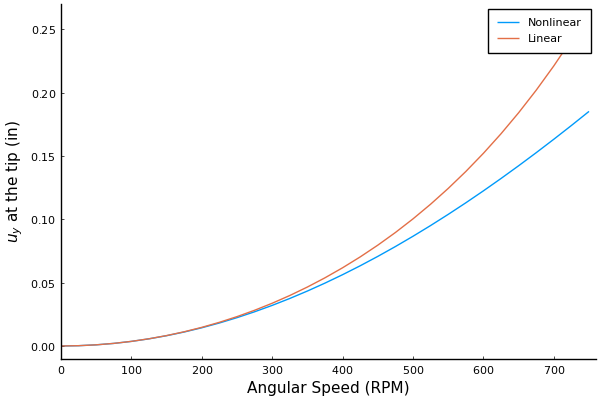

In [5]:
# y tip deflection
plot(
    xlim = (0, 760),
    xticks = 0:100:750,
    xlabel = "Angular Speed (RPM)",
    ylim = (-0.01, 0.27),
    yticks = 0.0:0.05:0.25,
    ylabel = "\$u_y\$ at the tip (in)",
    grid = false,
    overwrite_figure=false
    )
uy_nl = [nonlinear_states[i].points[end].u[2] for i = 1:length(rpm)]
uy_l = [linear_states[i].points[end].u[2] for i = 1:length(rpm)]
plot!(rpm, uy_nl, label="Nonlinear")
plot!(rpm, uy_l, label="Linear")

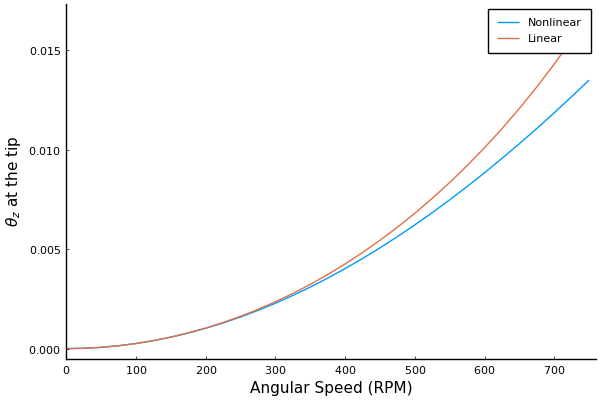

In [6]:
# rotation of the tip
plot(
    xlim = (0, 760),
    xticks = 0:100:750,
    xlabel = "Angular Speed (RPM)",
    ylabel = "\$θ_z\$ at the tip",
    grid = false,
    overwrite_figure=false
    )
theta_z_nl = [4*atan(nonlinear_states[i].points[end].theta[3]/4)
    for i = 1:length(rpm)]
theta_z_l = [4*atan(linear_states[i].points[end].theta[3]/4)
    for i = 1:length(rpm)]

plot!(rpm, theta_z_nl, label="Nonlinear")
plot!(rpm, theta_z_l, label="Linear")

## Eigenvalue Analysis

We will now compute the eigenvalues of this system for a range of sweep angles and and
angular speeds.

In [7]:
sweep = (0:2.5:45) * pi/180
rpm = [0, 500, 750]
nev = 30

λ = Matrix{Vector{ComplexF64}}(undef, length(sweep), length(rpm))
U = Matrix{Matrix{ComplexF64}}(undef, length(sweep), length(rpm))
V = Matrix{Matrix{ComplexF64}}(undef, length(sweep), length(rpm))
state = Matrix{AssemblyState{Float64}}(undef, length(sweep), length(rpm))
eigenstates = Matrix{Vector{AssemblyState{ComplexF64}}}(undef, length(sweep), length(rpm))

for i = 1:length(sweep)

    local L_b1, r_b1, nelem_b1, lengths_b1
    local xp_b1, xm_b1, Cab_b1
    local cs, ss
    local L_b2, r_b2, nelem_b2, frame_b2, lengths_b2
    local xp_b2, xm_b2, Cab_b2
    local nelem, points, start, stop
    local lengths, midpoints, Cab, compliance, mass, assembly

    # straight section of the beam
    L_b1 = 31.5 # inch
    r_b1 = [2.5, 0, 0]
    nelem_b1 = 20
    lengths_b1, xp_b1, xm_b1, Cab_b1 = discretize_beam(L_b1, r_b1, nelem_b1)

    # swept section of the beam
    L_b2 = 6 # inch
    r_b2 = [34, 0, 0]
    nelem_b2 = 4
    cs, ss = cos(sweep[i]), sin(sweep[i])
    frame_b2 = [cs ss 0; -ss cs 0; 0 0 1]
    lengths_b2, xp_b2, xm_b2, Cab_b2 = discretize_beam(L_b2, r_b2, nelem_b2;
        frame = frame_b2)

    # combine elements and points into one array
    nelem = nelem_b1 + nelem_b2
    points = vcat(xp_b1, xp_b2[2:end])
    start = 1:nelem_b1 + nelem_b2
    stop = 2:nelem_b1 + nelem_b2 + 1
    lengths = vcat(lengths_b1, lengths_b2)
    midpoints = vcat(xm_b1, xm_b2)
    Cab = vcat(Cab_b1, Cab_b2)

    compliance = fill(Diagonal([1/(E*A), 1/(G*Ay), 1/(G*Az), 1/(G*Jx),
        1/(E*Iyy), 1/(E*Izz)]), nelem)

    mass = fill(Diagonal([ρ*A, ρ*A, ρ*A, ρ*J, ρ*Iyy, ρ*Izz]), nelem)

    # create assembly
    assembly = Assembly(points, start, stop;
        compliance = compliance,
        mass = mass,
        frames = Cab,
        lengths = lengths,
        midpoints = midpoints)

    # create system
    system = DynamicSystem(assembly)

    for j = 1:length(rpm)

        # global frame rotation
        w0 = [0, 0, rpm[j]*(2*pi)/60]

        # define previous left eigenvector matrix (used for correlating eigenmodes)
        if i == 1 && j == 1
            Uprev = nothing
        elseif i == 1
            Uprev = U[i,j-1]
        else
            Uprev = U[i-1,j]
        end

        # eigenvalues and eigenvectors
        system, λ[i,j], U[i,j], V[i,j], converged = eigenvalue_analysis!(system, assembly;
            angular_velocity = w0,
            prescribed_conditions = prescribed_conditions,
            nev = nev,
            left = true,
            Uprev = Uprev)

        # post-process state variables
        state[i,j] = AssemblyState(system, assembly; prescribed_conditions)

        # post-process eigenvector state variables
        eigenstates[i,j] = [
            AssemblyState(V[i,j][:,k], system, assembly; prescribed_conditions)
            for k = 1:nev
        ]
    end
end

# extract frequencies
frequency = [
    [imag(λ[i,j][k])/(2*pi) for i = 1:length(sweep), j=1:length(rpm)] for k = 1:2:nev
    ]

nothing #hide

Note that we correlated each eigenmode by taking advantage of the fact that left and right
eigenvectors satisfy the following relationships:

$$
\begin{aligned}
u^H M v &= 1 &\text{if \(u\) and \(v\) correspond to the same eigenmode} \\
u^H M v &= 0 &\text{if \(u\) and \(v\) correspond to different eigenmodes}
\end{aligned}
$$

In this case these eigenmode correlations work, but remember that large changes in the
underlying parameters (or just drastic changes in the eigenvectors themselves due to a
small perturbation) can cause these correlations to fail.

## Comparison with Experimental Results

We'll now plot the frequency of the different eigenmodes against those found by Epps and
Chandra in "The Natural Frequencies of Rotating Composite Beams With Tip Sweep".

In [8]:
# index of first bending mode
index = 1

# experimental data
experiment_sweep = [0, 15, 30, 45]
experiment_rpm = [0, 500, 750]
experiment_frequencies = [
    1.4 10.2 14.8;
    1.8 10.1 14.4;
    1.7 10.2 14.9;
    1.6 10.2 14.7;
]

# initialize plot
plot(
    xlabel = "Sweep Angle (degrees)",
    xticks = 0:15:45,
    xlim = (0, 45),
    ylabel = "Frequency (Hz)",
    yticks = 0:2.5:20.0,
    ylim = (0, 20),
    grid = false,
    legend= :topright,
    overwrite_figure=false,
    )

# initialize legend entries
plot!([], [], color=:black, label="GXBeam")
scatter!([], [], color=:black, label = "Experiment")

# plot frequency for each rotation rate
for j = 1:length(rpm)
    # gxbeam
    plot!(sweep*180/pi, frequency[index][:,j], label="", color=colors[j])
    # experimental
    scatter!(experiment_sweep, experiment_frequencies[:,j], label="", color=colors[j])
    # annotation
    iann = round(Int, 1/4*length(sweep))
    xann = sweep[iann]*180/pi
    yann = frequency[index][iann,j] + 1.5
    annotate!(xann, yann, text("$(rpm[j]) RPM", 8, :center, :bottom, colors[j]))
end

In [9]:
# index of second bending mode
index = 2

# experimental data
experiment_sweep = [0, 15, 30, 45]
experiment_rpm = [0, 500, 750]
experiment_frequencies = [
    10.3  25.2  36.1;
    10.2  25.2  34.8;
    10.4  23.7  30.7;
    10.4  21.6  26.1;
]

# initialize plot
plot(
    xlabel = "Sweep Angle (degrees)",
    xticks = 0:15:45,
    xlim = (0, 45),
    ylabel = "Frequency (Hz)",
    yticks = 0:5:45,
    ylim = (0, 45),
    grid = false,
    legend = :topright,
    overwrite_figure=false
    )

# initialize legend entries
plot!([], [], color=:black, label="GXBeam")
scatter!([], [], color=:black, label = "Experiment")

# plot frequency for each rotation rate
for j = 1:length(rpm)
    # gxbeam
    plot!(sweep*180/pi, frequency[index][:,j], label="", color=colors[j])
    # experimental
    scatter!(experiment_sweep, experiment_frequencies[:,j], label="", color=colors[j])
    # annotation
    iann = round(Int, 1/4*length(sweep))
    xann = sweep[iann]*180/pi
    yann = frequency[index][iann,j] + 1.5
    annotate!(xann, yann, text("$(rpm[j]) RPM", "Serif", 8, :center, :bottom, colors[j]))
end

In [10]:
# index of third bending mode
index = 4

# experimental data
experiment_sweep = [0, 15, 30, 45]
experiment_rpm = [0, 500, 750]
experiment_frequencies = [
    27.7  47.0  62.9
    27.2  44.4  55.9
    26.6  39.3  48.6
    24.8  35.1  44.8
]

# initialize plot
plot(
    xlabel = "Sweep Angle (degrees)",
    xticks = 0:15:45,
    xlim = (0, 45),
    ylabel = "Frequency (Hz)",
    yticks = 0:10:70.0,
    ylim = (0, 70),
    grid = false,
    legend = :bottomright,
    overwrite_figure=false
    )

# initialize legend entries
plot!([], [], color=:black, label="GXBeam")
scatter!([], [], color=:black, label = "Experiment")

# plot frequency for each rotation rate
for j = 1:length(rpm)
    # gxbeam
    plot!(sweep*180/pi, frequency[index][:,j], label="", color=colors[j])
    # experimental
    scatter!(experiment_sweep, experiment_frequencies[:,j], label="", color=colors[j])
    # annotation
    iann = round(Int, 1/4*length(sweep))
    xann = sweep[iann]*180/pi
    yann = frequency[index][iann,j] + 1.5
    annotate!(xann, yann, text("$(rpm[j]) RPM", "Serif", 8, :center, :bottom, colors[j]))
end

In [11]:
# names and indices of modes
names = ["1T/5B", "5B/1T", "4B/1T"]
indices = [5, 7, 6]

# experimental data
experiment_sweep = [0, 15, 30, 45]
experiment_rpm = 750
experiment_frequencies = [
    95.4  106.6  132.7;
    87.5  120.1  147.3;
    83.7  122.6  166.2;
    78.8  117.7  162.0;
]

# initialize plot
plot(
    xlabel = "Sweep Angle (degrees)",
    xticks = 0:15:45,
    xlim = (0, 45),
    ylabel = "Frequency (Hz)",
    yticks = 0:20:180,
    ylim = (0, 180),
    grid = false,
    legend = :bottomright,
    overwrite_figure=false,
    )

# initialize legend entries
plot!([], [], color=:black, label="GXBeam")
scatter!([], [], color=:black, label = "Experiment")

for k = 1:length(indices)
    # gxbeam
    plot!(sweep*180/pi, frequency[indices[k]][:,end]; label="", color=colors[k])
    # experimental
    scatter!(experiment_sweep, experiment_frequencies[:,k]; label="", color=colors[k])
    # annotation
    iann = round(Int, 1/4*length(sweep))
    xann = sweep[iann]*180/pi
    yann = frequency[indices[k]][iann,end] + 1.5
    annotate!(xann, yann, text("$(names[k])", "Serif", 8, :center, :bottom, colors[k]))
end

As you can see, the frequency results from the eigenmode analysis in this package
compare well with experimental results.

## Eigenmode Visualization

We can also visualize eigenmodes using ParaView.  Here we will visualize the first
bending mode for the 45 degree swept tip at a rotational speed of 750 RPM.  This can be
helpful for identifying different eigenmodes.

In [12]:
# write the response to vtk files for visualization using ParaView
mkpath("rotating-eigenmode")
write_vtk("rotating-eigenmode/rotating-eigenmode", assembly, state[end,end],
    λ[end,end][1], eigenstates[end,end][1]; mode_scaling = 100.0)

![](../assets/rotating-eigenmode.gif)

## Sensitivity Analysis

Suppose we are interested in computing the sensitivity of the mode frequencies to sweep
angle when rotating at 750 RPM with a \SI{45}{\deg} sweep angle.  We can compute these
sensitivities as follows:

In [13]:
using ForwardDiff

# number of eigenvalues
nev = 30

# define sweep angle
sweep = 45 * pi/180

# define RPM
rpm = 750

# define parameter vector
p = [sweep]

# straight section of the beam
L_b1 = 31.5 ## inch
r_b1 = [2.5, 0, 0]
nelem_b1 = 20
lengths_b1, xp_b1, xm_b1, Cab_b1 = discretize_beam(L_b1, r_b1, nelem_b1)

# swept section of the beam
L_b2 = 6 ## inch
r_b2 = [34, 0, 0]
nelem_b2 = 4
cs, ss = cos(sweep), sin(sweep)
frame_b2 = [cs ss 0; -ss cs 0; 0 0 1]
lengths_b2, xp_b2, xm_b2, Cab_b2 = discretize_beam(L_b2, r_b2, nelem_b2; frame = frame_b2)

# combine elements and points into one array
nelem = nelem_b1 + nelem_b2
points = vcat(xp_b1, xp_b2[2:end])
start = 1:nelem_b1 + nelem_b2
stop = 2:nelem_b1 + nelem_b2 + 1
Cab = vcat(Cab_b1, Cab_b2)

# define compliance
compliance = fill(Diagonal([1/(E*A), 1/(G*Ay), 1/(G*Az), 1/(G*Jx), 1/(E*Iyy),
1/(E*Izz)]), nelem)

# define mass
mass = fill(Diagonal([ρ*A, ρ*A, ρ*A, ρ*J, ρ*Iyy, ρ*Izz]), nelem)

# create (default) assembly
assembly = Assembly(points, start, stop;
    compliance = compliance,
    mass = mass,
    frames = Cab)

# construct parameter function which overwrites the default assembly
pfunc = (p, t) -> begin

    sweep = p[1] # sweep angle

    # redefine swept section of the beam
    cs, ss = cos(sweep), sin(sweep)
    frame_b2 = [cs ss 0; -ss cs 0; 0 0 1]
    lengths_b2, xp_b2, xm_b2, Cab_b2 = discretize_beam(L_b2, r_b2, nelem_b2; frame = frame_b2)

    # redefine points and reference frame
    points = vcat(xp_b1, xp_b2[2:end])
    Cab = vcat(Cab_b1, Cab_b2)

    # create new assembly
    assembly = Assembly(points, start, stop;
        compliance = compliance,
        mass = mass,
        frames = Cab)

    # return named tuple with new arguments
    return (; assembly=assembly)
end

# construct objective function
objfun = (p) -> begin

    # perform eigenvalue analysis
    system, λ, V, converged = eigenvalue_analysis(assembly; pfunc, p,
        angular_velocity = [0, 0, rpm*(2*pi)/60],
        prescribed_conditions = prescribed_conditions,
        eigenvector_sensitivities=true,
        nev = nev)

    # return frequencies
    return [imag(λ[k])/(2*pi) for k = 1:2:length(λ)]
end

# compute sensitivities using ForwardDiff with λ = 1.0
ForwardDiff.jacobian(objfun, p)

15×1 Matrix{Float64}:
   0.03674527226999975
   0.8983685948148523
 -12.140533981457994
  -9.537080532059463
  -9.253326335751323
  -7.316987305572131
   8.101457732270138
  -0.7316380937250151
  57.19730367308137
 -18.115542110001314
 -14.508055028310393
 103.8577498637061
 -16.73939558171815
   3.8256004260694483
  -3.7841772226467665

Note the use of the keyword argument `eigenvector_sensitivities=false` in our call to
`eigenvalue_analysis`.  This keyword argument tells the solver that we are only interested
in eigenvalue derivatives, rather than eigenvalue and eigenvector derivatives.  Setting
this keyword argument to `false` (when appropriate) significantly reduces the computational
expenses associated with computing design sensitivities.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*